# Gradient Boosting Regression

## Notebook Objective

This notebook tests a Gradient Boosting Regressor for monthly cost prediction.

The goal is to evaluate whether a sequential tree-based ensemble can improve prediction performance compared with the previous Random Forest and regularized linear regression models.

Gradient Boosting builds trees sequentially, where each new tree tries to correct errors made by the previous trees.

This notebook focuses on nonlinear model performance, residual behavior, feature importance, and comparison against prior models.

## 1. Imports

In [1]:
import pandas as pd # Load and manipulate tabular data
import numpy as np # Numerical calculations

import matplotlib.pyplot as plt # Create plots

from sklearn.model_selection import train_test_split # Split data into train/test sets
from sklearn.compose import ColumnTransformer # Apply preprocessing by column type
from sklearn.preprocessing import OneHotEncoder # Encode categorical variables
from sklearn.pipeline import Pipeline # Combine preprocessing and model steps

from sklearn.ensemble import GradientBoostingRegressor # Main Day 15 Model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # Regression Metrics








## 2. Load Data

In [2]:
df = pd.read_csv("../data/processed/member_analysis_ready.csv") # Load processed feature dataset 

df.head()

,member_id,age,gender,region,plan_type,sdoh_risk_score,chronic_condition_count,engagement_score,pcp_attributed_24mo,prior_awv_count,...,engagement_group,age_group,high_cost_member,chronic_burden_group,sdoh_risk_group,prior_awv_group,total_acute_visits,acute_utilization_group,pcp_status,has_acute_utilization
0,M00001,69,Male,Suburban,Medicare Advantage,40.7,2,68.9,1,1,...,Q4_High,65-79,1,Moderate,Q1_Low,1,2,Low,Attributed,1
1,M00002,32,Female,Urban,DSNP,80.0,3,30.4,0,0,...,Q1_Low,18-34,0,Moderate,Q4_High,0,2,Low,Not Attributed,1
2,M00003,89,Female,Suburban,Medicare Advantage,49.6,3,86.3,1,3,...,Q4_High,80+,0,Moderate,Q2,3,0,NaN,Attributed,0
3,M00004,78,Male,Suburban,Medicare Advantage,45.7,4,63.1,1,1,...,Q4_High,65-79,1,High,Q1_Low,1,3,Moderate,Attributed,1
4,M00005,38,Male,Suburban,Medicare Advantage,32.4,0,55.6,0,0,...,Q4_High,35-49,0,Low,Q1_Low,0,0,NaN,Not Attributed,0


## 3. Define target and features

In [3]:
target = "monthly_cost" # Regression target

drop_cols = [
    "member_id",              # Identifier, not a predictive feature
    target,                   # Target variable must be removed from predictors
    "high_cost_member",       # Derived from monthly_cost, causes target leakage
    "awv_completed",          # Excluded to keep cost prediction focused on risk/access/utilization

    # Full-dataset grouped/qcut features or redundant engineered features
    "engagement_group",
    "sdoh_risk_group",
    "age_group",
    "chronic_burden_group",
    "pcp_status",
    "prior_awv_group",
    "total_acute_visits",
    "acute_utilization_group",
    "has_acute_utilization",

    # Redundant with prior_awv_rate
    "prior_awv_count"
]


X = df.drop(columns=drop_cols) # Create feature matrix
y = df[target]




## Feature Selection Logic

This notebook uses the same cleaned cost-prediction feature set as the prior regression notebooks.

The model excludes `member_id`, `high_cost_member`, `awv_completed`, full-dataset grouped features, and redundant engineered variables.

`high_cost_member` is excluded because it is derived from `monthly_cost` and would create target leakage.

Grouped features such as `engagement_group`, `sdoh_risk_group`, and `chronic_burden_group` are excluded because the raw source variables are already included.

Derived utilization variables such as `total_acute_visits`, `acute_utilization_group`, and `has_acute_utilization` are excluded because `ed_visits` and `ip_admits` are already included separately.

This keeps the Gradient Boosting comparison consistent with the previous cost-regression notebooks.

## 4. Detect column types

In [4]:
categorical_cols = X.select_dtypes(
    include=["object", "string", "category", "bool"]
).columns.tolist() # Identify categorical columns

numeric_cols = X.select_dtypes(
    include=["int64","float64","int32","float32"]
).columns.tolist() # Identify numeric_cols

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)






Categorical columns: ['gender', 'region', 'plan_type']
Numeric columns: ['age', 'sdoh_risk_score', 'chronic_condition_count', 'engagement_score', 'pcp_attributed_24mo', 'prior_awv_rate', 'ed_visits', 'ip_admits']


## 5. Train/test split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,             # Feature matrix
    y,             # Target vector
    test_size=0.20, # Use 20% as test set
    random_state=42 # Make split reproducible 
)

## 6. Build preprocessor

In [6]:
preprocessor = ColumnTransformer(
    transformers = [
        (
            "cat",
            OneHotEncoder(handle_unknown = "ignore"),
            categorical_cols
        )
    ], 
    remainder = "passthrough" # Keep numeric columns unchanged
)

## 7. Build Gradient Boosting model

## Why Use Gradient Boosting Regression?

Gradient Boosting is an ensemble tree-based method.

Unlike Random Forest, which builds many trees independently and averages their predictions, Gradient Boosting builds trees sequentially.

Each new tree attempts to reduce the errors left by the previous trees.

This can make Gradient Boosting powerful for nonlinear prediction problems, but it can also overfit if the model is too complex or if the learning rate and number of trees are not controlled.

In this notebook, the model uses a small learning rate, shallow trees, and a minimum leaf size to reduce overfitting risk.

In [7]:
gb_model = Pipeline(
    steps = [
        ("preprocessor", preprocessor), # Encode categorical variables 
        (
            "model",
            GradientBoostingRegressor(
                n_estimators = 200, # Number of boosting stages
                learning_rate=0.05, # Smaller learning rate makes learning more gradual 
                max_depth = 3, # Shallow trees reduce overfitting 
                min_samples_leaf = 10, # Prevent tiny leaves
                random_state = 42 # Reproducible model
            )
        )
    ]
)

## 8. Fit Model

In [8]:
gb_model.fit(X_train, y_train) # Train Gradient Boosting model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

## 9. Evaluate model

In [9]:
y_train_pred = gb_model.predict(X_train) # Predict training data
y_test_pred = gb_model.predict(X_test) # Predict test data

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae =  mean_absolute_error(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

gb_results = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "MAE": [train_mae, test_mae],
    "RMSE": [train_rmse, test_rmse],
    "R2": [train_r2, test_r2]
})


gb_results



,Dataset,MAE,RMSE,R2
0,Train,296.400011,475.781214,0.857280
1,Test,370.865428,643.577656,0.771507


## Gradient Boosting Performance Interpretation

The Gradient Boosting model achieved test MAE of about `$371`, test RMSE of about `$644`, and test R² of about `0.772`.

The training performance is stronger than the test performance, which is expected. The train R² is about `0.857`, while the test R² is about `0.772`.

This gap suggests some overfitting, but the test performance is still strong compared with previous tree-based models.

The RMSE is higher than the MAE, which means the model still has some larger prediction errors, likely among high-cost members.

## 10. Actual vs predicted plot

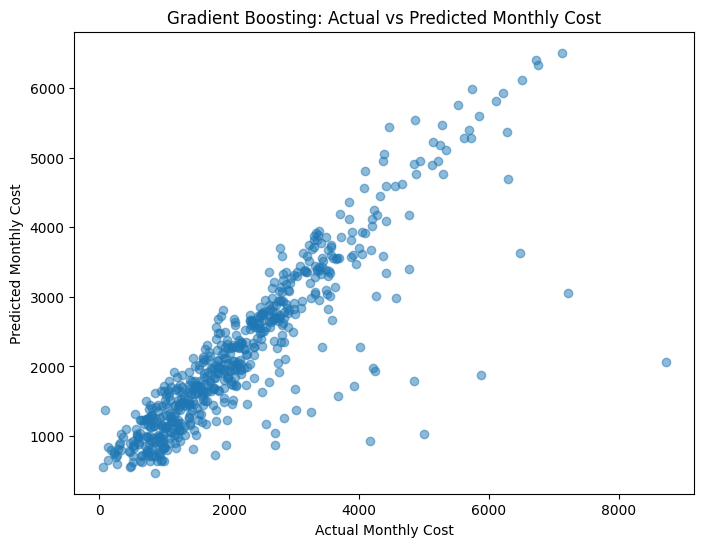

In [10]:
plt.figure(figsize = (8,6))

plt.scatter(y_test, y_test_pred, alpha = 0.5)

plt.xlabel("Actual Monthly Cost")
plt.ylabel("Predicted Monthly Cost")
plt.title("Gradient Boosting: Actual vs Predicted Monthly Cost")

plt.show()


## Actual vs Predicted Plot Interpretation

The actual-vs-predicted plot compares the model’s predicted monthly cost against the true monthly cost.

Points closer to the diagonal pattern represent better predictions.

The plot helps show whether the model captures the overall cost pattern and whether it struggles with very high-cost members.

## 11. Residual plot

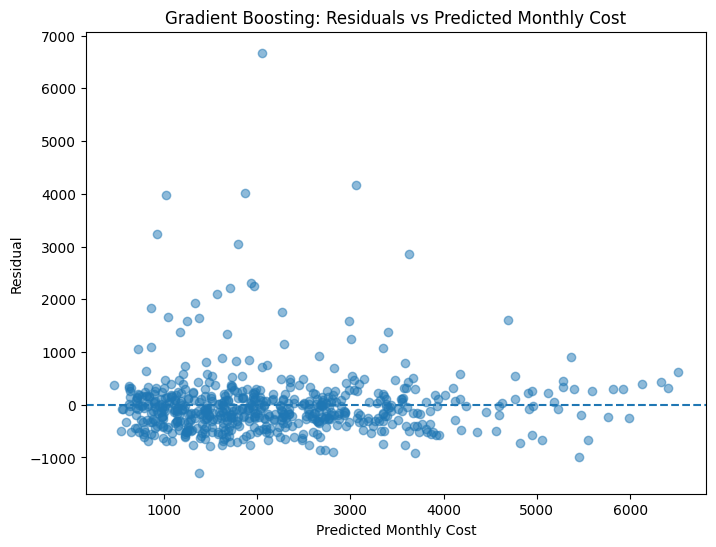

In [11]:
residuals = y_test - y_test_pred # Calculate prediction errors

plt.figure(figsize = (8,6))

plt.scatter(y_test_pred, residuals, alpha = 0.5)
plt.axhline(0, linestyle = "--")

plt.xlabel("Predicted Monthly Cost")
plt.ylabel("Residual")
plt.title("Gradient Boosting: Residuals vs Predicted Monthly Cost")

plt.show()

## Residual Plot Interpretation

Residuals are calculated as:

`actual monthly cost - predicted monthly cost`

A positive residual means the model underpredicted cost. A negative residual means the model overpredicted cost.

The residual plot is used to check whether errors are randomly scattered or whether the model systematically misses certain cost ranges.

If residuals widen at higher predicted costs, that suggests the model still has difficulty with high-cost members.

## 12. Feature importance

In [12]:
trained_preprocessor = gb_model.named_steps["preprocessor"]
trained_gb = gb_model.named_steps["model"] # Access fitted Gradient Boosting model

feature_names = trained_preprocessor.get_feature_names_out() # Get transformed feature names

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": trained_gb.feature_importances_
}).sort_values(by = "importance", ascending = False)

importance_df.head(20)





,feature,importance
10,remainder__chronic_condition_count,0.536649
15,remainder__ip_admits,0.300549
14,remainder__ed_visits,0.082365
5,cat__plan_type_DSNP,0.025603
8,remainder__age,0.021103
11,remainder__engagement_score,0.016162
9,remainder__sdoh_risk_score,0.007608
6,cat__plan_type_Medicaid,0.005695
12,remainder__pcp_attributed_24mo,0.002077
2,cat__region_Rural,0.000969


## 13. Plot top feature importances

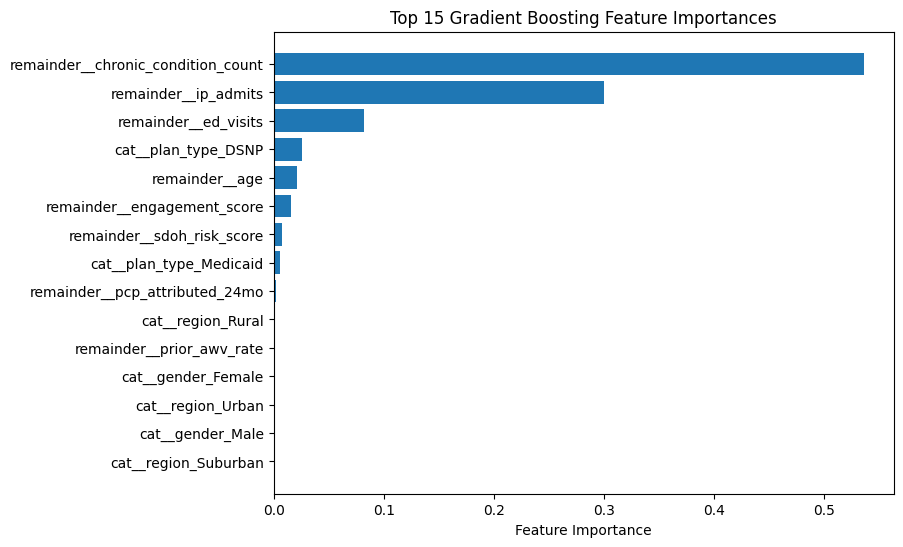

In [13]:
top_features = importance_df.head(15).sort_values(by="importance") # Sort for horizontal chart

plt.figure(figsize = (8,6))

plt.barh(top_features["feature"], top_features["importance"])

plt.xlabel("Feature Importance")
plt.title("Top 15 Gradient Boosting Feature Importances")

plt.show()

## Feature Importance Interpretation

The Gradient Boosting model relied most heavily on chronic condition count, inpatient admissions, and ED visits.

This aligns with the synthetic data-generation logic, where chronic burden and acute utilization are major drivers of monthly cost.

Feature importance measures predictive usefulness inside this fitted model. It does not prove causality.

A high-importance feature means the model used that feature frequently or effectively to reduce prediction error, not that the feature directly causes higher cost.

# 14. Compare with previous models

In [14]:
model_comparison = pd.DataFrame({
    "Model": [
        "Tuned Ridge",
        "Controlled Decision Tree",
        "Baseline Random Forest",
        "Tuned Random Forest",
        "Gradient Boosting"
    ],
    "Test MAE": [
        404.17,   # update if your final tuned Ridge value differs
        449.00,   # update if your final controlled tree value differs
        398.03,
        392.53,
        test_mae
    ],
    "Test RMSE": [
        654.24,   # update if your final tuned Ridge value differs
        709.00,   # update if your final controlled tree value differs
        671.46,
        668.57,
        test_rmse
    ],
    "Test R²": [
        0.764,
        0.723,
        0.751,
        0.753,
        test_r2
    ]
})

model_comparison

,Model,Test MAE,Test RMSE,Test R²
0,Tuned Ridge,404.170000,654.240000,0.764000
1,Controlled Decision Tree,449.000000,709.000000,0.723000
2,Baseline Random Forest,398.030000,671.460000,0.751000
3,Tuned Random Forest,392.530000,668.570000,0.753000
4,Gradient Boosting,370.865428,643.577656,0.771507


## 15. Findings markdown

## Final Findings

This notebook tested a Gradient Boosting Regressor for monthly cost prediction.

The model used the same cleaned cost-prediction feature set as the prior regression notebooks to avoid leakage and maintain comparison consistency.

Gradient Boosting is a sequential ensemble method. Unlike Random Forest, which averages many independent trees, Gradient Boosting builds trees one after another so each new tree attempts to reduce previous prediction errors.

The Gradient Boosting model achieved test MAE of about `$371`, test RMSE of about `$644`, and test R² of about `0.772`.

Compared with the tuned Random Forest, Gradient Boosting produced lower MAE, lower RMSE, and higher R².

Compared with the tuned Ridge model, Gradient Boosting also showed slightly better test RMSE and R² in this run.

The model still showed some train-test performance gap, so mild overfitting is possible, but test performance remained strong.

Feature importance showed that chronic condition count, inpatient admissions, and ED visits were the most important predictors in the fitted Gradient Boosting model.

Feature importance values show predictive usefulness inside the fitted model. They do not prove causal effects.

Because this project uses synthetic data, these findings reflect the data-generation assumptions rather than real-world healthcare evidence.

A logical next step is to tune the Gradient Boosting hyperparameters or compare all models in a final model comparison notebook.